# MiBiPreT example: Metabolite Data Analysis with Amersfoort data

Diagnostic plots for data analysis on microbial biodegredation at the contaminant Amersfoort site. 

Author: Alraune Zech

Data based on the PhD thesis of *Johan van Leeuwen*, 2021 'Biodegredation of mono- and polyaromatic hydrocarbons in a contaminated aquifer originating from a former Pintsch gas factory site' which is equivalent to the manuscript of van Leeuwen et al., 2022 'Anaerobic degradation of benzene and other aromatic hydrocarbons in a tar-derived plume: Nitrate versus iron reducing conditions', J. of Cont. Hydrol. The data was provided by Johan van Leeuwen.
  
## Background: Amersfoort contaminant site

Close to the train station in Amersfoort, the Netherlands, the subsurface is contaminated with organic hydrocarbons forming a NAPL. Contamination originates from decades of operating manufactured gas plant, which dumped tar by-products in waste lagoons. The tar is a DNAPL and has spread into the underlying shallow unconfined aquifer. Sample wells were installed to measure various characteristics of the subsurface. The raw data contains measurements on
* environmental conditions, such as pH, redox potential, concentrations of oxygen, nitrate, etc
* contaminant concentration such as BTEX, indene, indane, naphtalene and multiple other (typically cyclic) petroleum hydrocarbons
* metabolite concentration, i.e. byproducts of degredation processes of contaminant
* isotope measurments for specific contaminants and samples
* counts of genes (RNA/DNA) of mibrobiota that is know to perform biodegredation as well as functional enzymes know to be responsible for biodegredation

**Required packages**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import mibiscreen as mbs

/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/reduction/transformation.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


## Data loading

In [3]:
file_path = './amersfoort.xlsx'

Load and standardize data of metabolites

In [4]:
metabolites_raw,units = mbs.load_excel(file_path,
                                       sheet_name = 'metabolites',
                                       verbose = False)

metabolites,units = mbs.standardize(metabolites_raw,
                                    reduce = False,
                                    verbose=False)

# metabolites_columns = mbs.check_columns(metabolites_raw,verbose = False)
# metabolites_units_check = mbs.check_units(metabolites_raw,verbose = False)
# metabolites_pure = mbs.check_values(metabolites_raw,verbose = False)

#display(metabolites)

________________________________________________________________
________________________________________________________________


## Metabolites Concentration Analysis

### Calculating total concentration and counts of metabolites per sample

In [5]:
metabolites_total = mbs.total_concentration(metabolites,
                                            name_list = 'all',
                                            include_as = False,    
                                            # verbose = True
                                            )

Note that calculated values are not included to data frame as for further analysis all column (except settings) will be used. If including the total concentration, the value of total count will be overestimated by 1.

In [6]:
metabolites_count = mbs.total_count(metabolites,
                                    name_list = 'all', 
                                    include_as = False,    
                                    #verbose = True
                                    )


Previous two steps are equivalent to:

In [7]:
mbs.total_metabolites_concentration(metabolites,
                                    include = True,
                                    verbose = False)

/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/sample/concentrations.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[include_as] = tot_conc


1      39.0
2      58.0
3      29.9
4      38.4
5     123.0
6     374.3
7     142.7
8     655.4
9      57.7
10     61.2
11     41.4
12     36.2
13     51.9
14     87.9
15    110.6
16     48.3
17    156.2
18    140.8
19     76.0
20    124.0
21    104.2
22     87.5
23     53.9
24     50.9
25     50.9
26     32.5
27     68.5
28    106.2
29     33.7
30     51.9
31     50.9
32     48.9
dtype: float64

Now including results as own data column to data frame of *metabolites*:

In [8]:
print("Names of last two columns", metabolites.columns[-2:].values)

Names of last two columns ['Phenylbutyrate - isomer 1' 'metabolites_concentration']


In [9]:
mbs.total_metabolites_count(metabolites.iloc[:,:-1],
                            include = True,
                            verbose = False)


/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/sample/concentrations.py:244: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[include_as] = total_count


1      25
2      28
3      36
4      42
5      83
6     157
7     119
8     172
9      66
10     66
11     16
12     29
13     46
14     78
15    107
16     42
17    111
18     99
19     55
20    133
21    126
22     72
23     48
24     52
25     33
26     16
27     55
28     96
29     17
30     20
31     21
32     17
dtype: int64

In [10]:
print("Names of last two columns", metabolites.columns[-2:].values)

Names of last two columns ['Phenylbutyrate - isomer 1' 'metabolites_concentration']


In [11]:
display(metabolites_total)

1      39.0
2      58.0
3      29.9
4      38.4
5     123.0
6     374.3
7     142.7
8     655.4
9      57.7
10     61.2
11     41.4
12     36.2
13     51.9
14     87.9
15    110.6
16     48.3
17    156.2
18    140.8
19     76.0
20    124.0
21    104.2
22     87.5
23     53.9
24     50.9
25     50.9
26     32.5
27     68.5
28    106.2
29     33.7
30     51.9
31     50.9
32     48.9
dtype: float64

equivalent to: (now including results as own data column to data frame of *metabolites*)

### Plotting total concentration of metabolites

Text(0.5, 1.0, 'Total concentration of metabolites per sample')

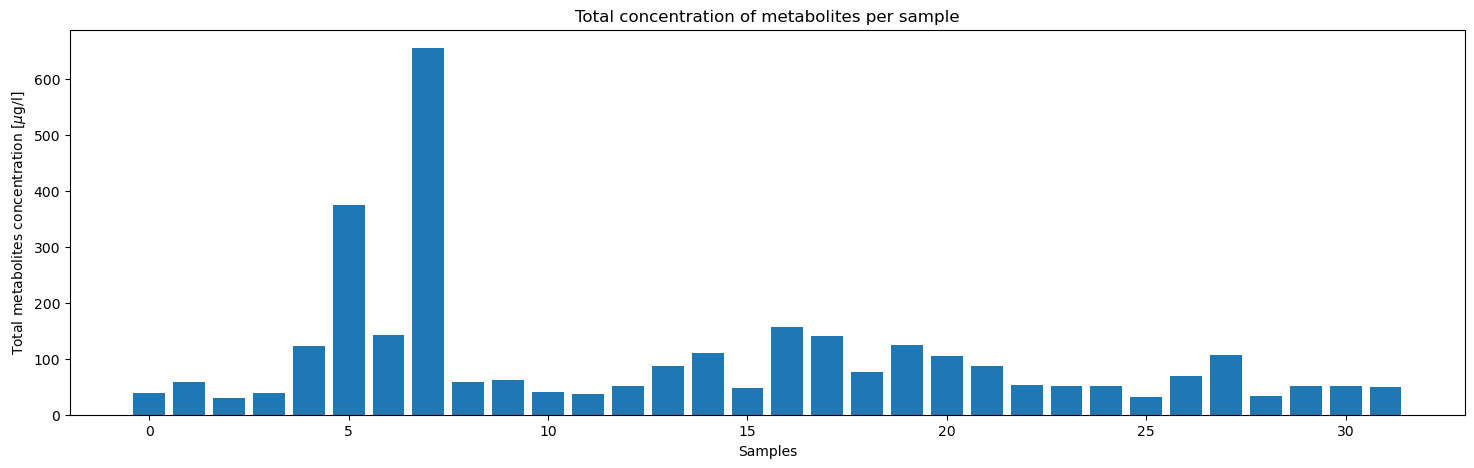

In [12]:
plt.figure(figsize = [18,5])
plt.bar(np.arange(len(metabolites_total.values)),metabolites_total.values,label='all')
plt.xlabel('Samples')
plt.ylabel(r'Total metabolites concentration [$\mu$g/l]')
plt.title('Total concentration of metabolites per sample')

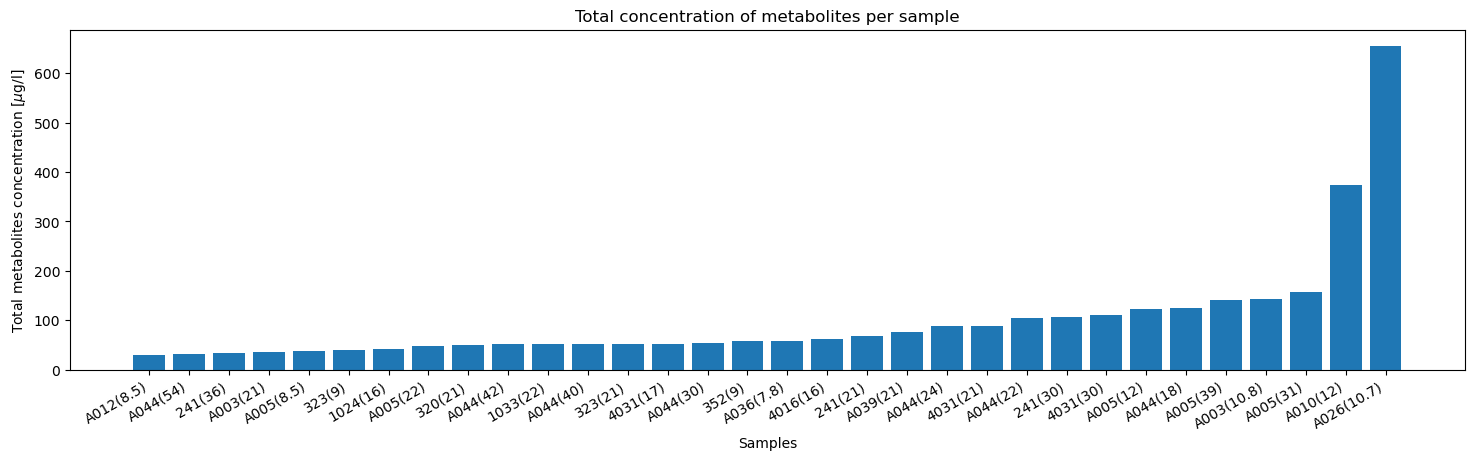

In [13]:
fig = plt.figure(figsize = [18,5])
sort_args = np.argsort(metabolites['metabolites_concentration'].values)
plt.bar(metabolites.sample_nr.values[sort_args],metabolites['metabolites_concentration'].values[sort_args],label='all')
plt.xlabel('Samples')
plt.ylabel(r'Total metabolites concentration [$\mu$g/l]')
plt.title('Total concentration of metabolites per sample')
fig.autofmt_xdate(bottom=0.2, rotation=30, ha='right', which='major')

### Plotting total counts of metabolites

Text(0.5, 1.0, 'Total number of metabolites per sample')

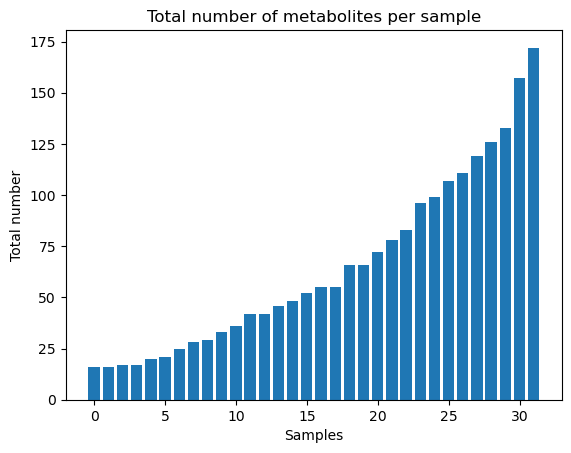

In [14]:
plt.bar(np.arange(len(metabolites_count.values)),np.sort(metabolites_count.values))
plt.xlabel('Samples')
plt.ylabel('Total number')
plt.title('Total number of metabolites per sample')
# plt.legend()

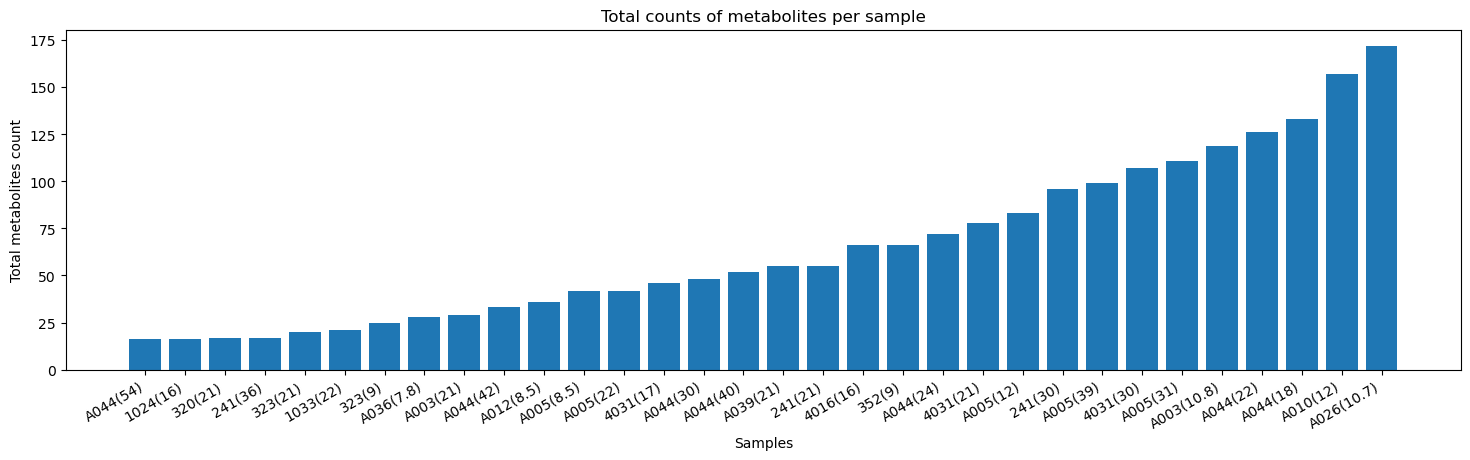

In [15]:
fig = plt.figure(figsize = [18,5])
sort_args = np.argsort(metabolites_count.values)
plt.bar(metabolites.sample_nr.values[sort_args],metabolites_count.values[sort_args],label='all')
plt.xlabel('Samples')
plt.ylabel(r'Total metabolites count')
plt.title('Total counts of metabolites per sample')
fig.autofmt_xdate(bottom=0.2, rotation=30, ha='right', which='major')

## Relating Metabolite activity to electron availability

### Load data of contaminants and geochemicals to identify electron availability and NA activity color

In [16]:
contaminants_raw,_ = mbs.load_excel(file_path,
                                    sheet_name = 'contaminants',
                                    verbose = False)
contaminants,units = mbs.standardize(contaminants_raw,verbose = False)
environment_raw,_ = mbs.load_excel(file_path,
                                   sheet_name = 'environment',
                                   verbose = False)
environment,units = mbs.standardize(environment_raw,verbose = False)

________________________________________________________________
________________________________________________________________
________________________________________________________________
________________________________________________________________
________________________________________________________________
________________________________________________________________


In [17]:
mbs.total_contaminant_concentration(contaminants,include = True)
mbs.total_metabolites_count(metabolites,include = True)
data_NA = mbs.merge_data([environment,contaminants,metabolites])
mbs.sample_NA_traffic(data_NA,include = True)

Maybe data not in standardized format. Run 'standardize()' first.
_________________________________________________________________
Maybe data not in standardized format. Run 'standardize()' first.
_________________________________________________________________


/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/sample/concentrations.py:244: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[include_as] = total_count


0     green
1     green
2     green
3     green
4     green
5     green
6     green
7     green
8     green
9     green
10    green
11      red
12      red
13      red
14      red
15    green
16      red
17      red
18    green
19    green
20    green
21      red
22    green
23      red
24      red
25      red
26      red
27      red
28      red
29      red
30      red
31    green
32    green
Name: na_traffic_light, dtype: object

### Activity plot linking contaminant concentration to metabolite occurence and NA screening

In [18]:
data_activity =  mbs.activity_data_prep(data_NA)
data_activity['tot_cont'] = data_activity['tot_cont']*0.001

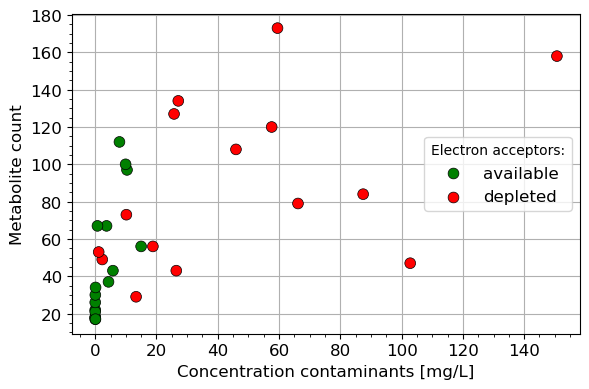

In [19]:
#fig, ax = mbs.activity_plot(data_activity)
fig, ax = mbs.activity_plot(data_activity,
                       figsize = [6,4],
                       textsize = 12,
                       xscale = 'log',
                       markersize = 60,
                       loc='center right',
                       xlabel = r"Concentration contaminants [mg/L]",
                       #save_fig = 'activity.png'
                       )